# Chapter 2: Bayes' Theorem and the Bayesian Framework

The single most important equation in this curriculum:

$$P(\theta \mid D) = \frac{P(D \mid \theta) \cdot P(\theta)}{P(D)}$$

In this notebook we derive it from scratch, explore sequential updating, conjugate priors,
and compute credible intervals — all with astrophysical examples.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
print("Ready.")


Ready.


## 2.1 Deriving Bayes' Theorem

From the definition of conditional probability:
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B \mid A) = \frac{P(A \cap B)}{P(A)}$$

Both share P(A∩B). Setting them equal and rearranging:
$$\boxed{P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)}}$$

For inference with parameters θ and data D:

| Term | Name | Meaning |
|------|------|---------|
| P(θ|D) | **Posterior** | Updated belief about θ after seeing D |
| P(D\|θ) | **Likelihood** | How well does θ explain the data? |
| P(θ) | **Prior** | Belief before seeing the data |
| P(D) | **Evidence** | Normalisation constant |


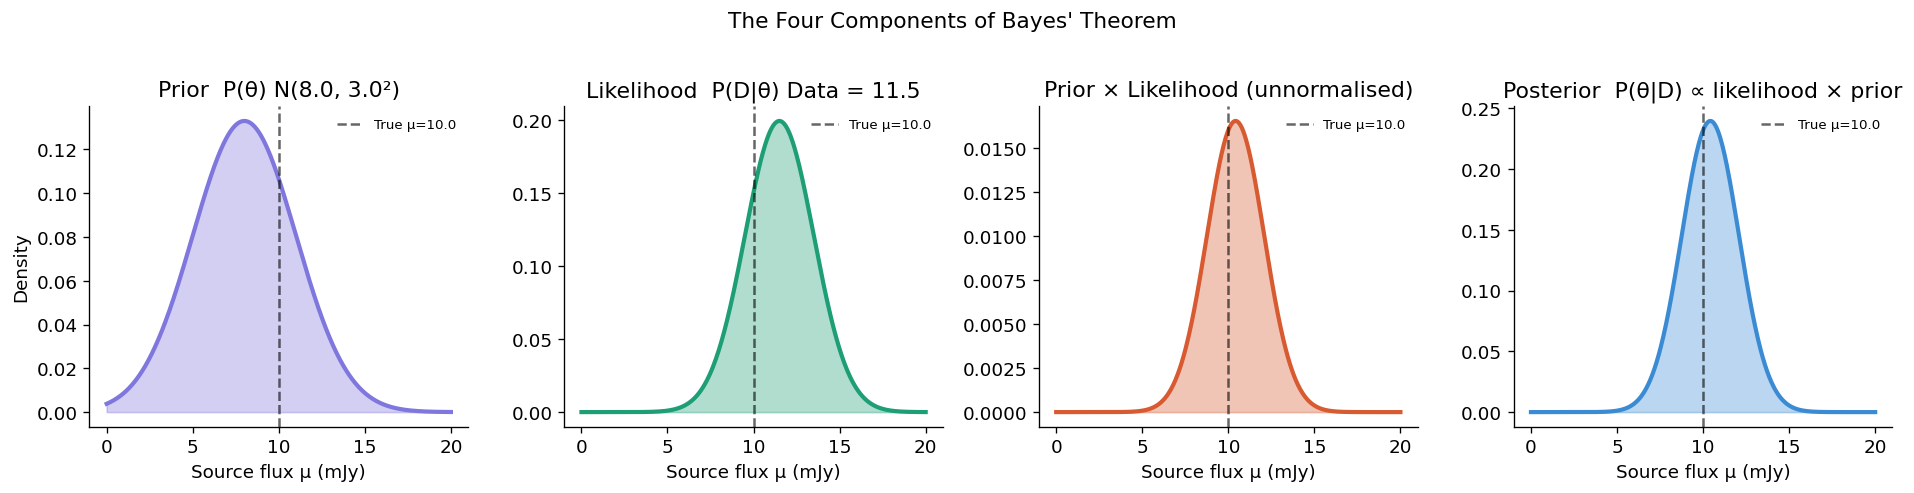

Evidence P(D) = 0.0691  (normalisation constant)


In [7]:
# Visualise the four components of Bayes' theorem on a simple example
# Estimating the mean flux of a source with one observation

mu_true = 10.0   # true flux (unknown to the model)
sigma   = 2.0    # known measurement noise
data    = 11.5   # single observation

mu_grid = np.linspace(0, 20, 500)

# Prior: broad Gaussian N(8, 3²)  -- "we think it's around 8 mJy"
prior_mu, prior_sig = 8.0, 3.0
prior = stats.norm.pdf(mu_grid, prior_mu, prior_sig)

# Likelihood: how probable is data=11.5 for each possible true flux?
likelihood = stats.norm.pdf(data, mu_grid, sigma)

# Unnormalised posterior
unnorm_post = likelihood * prior
posterior = unnorm_post / np.trapezoid(unnorm_post, mu_grid)  # normalise

# Evidence (just a scalar)
evidence = np.trapezoid(unnorm_post, mu_grid)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
components = [
    (prior,      "#7F77DD", f"Prior  P(θ) N({prior_mu}, {prior_sig}²)"),
    (likelihood, "#1D9E75", f"Likelihood  P(D|θ) Data = {data}"),
    (unnorm_post,"#D85A30", f"Prior × Likelihood (unnormalised)"),
    (posterior,  "#3B8BD4", f"Posterior  P(θ|D) ∝ likelihood × prior"),
]
for ax, (y, col, title) in zip(axes, components):
    ax.fill_between(mu_grid, y, alpha=0.35, color=col)
    ax.plot(mu_grid, y, col, lw=2.5)
    ax.axvline(mu_true, color="black", lw=1.5, ls="--", alpha=0.6, label=f"True μ={mu_true}")
    ax.set_xlabel("Source flux μ (mJy)")
    ax.set_title(title)
    if ax == axes[0]: ax.set_ylabel("Density")
    ax.legend(fontsize=8, frameon=False)

plt.suptitle("The Four Components of Bayes' Theorem", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Evidence P(D) = {evidence:.4f}  (normalisation constant)")


## 2.2 Sequential Bayesian Updating

A beautiful property: **yesterday's posterior is today's prior**.

We update beliefs one observation at a time. The final result is identical to
processing all data simultaneously — Bayes is consistent regardless of order.

**Example:** Estimating the mean flux of a quasar with three sequential observations.


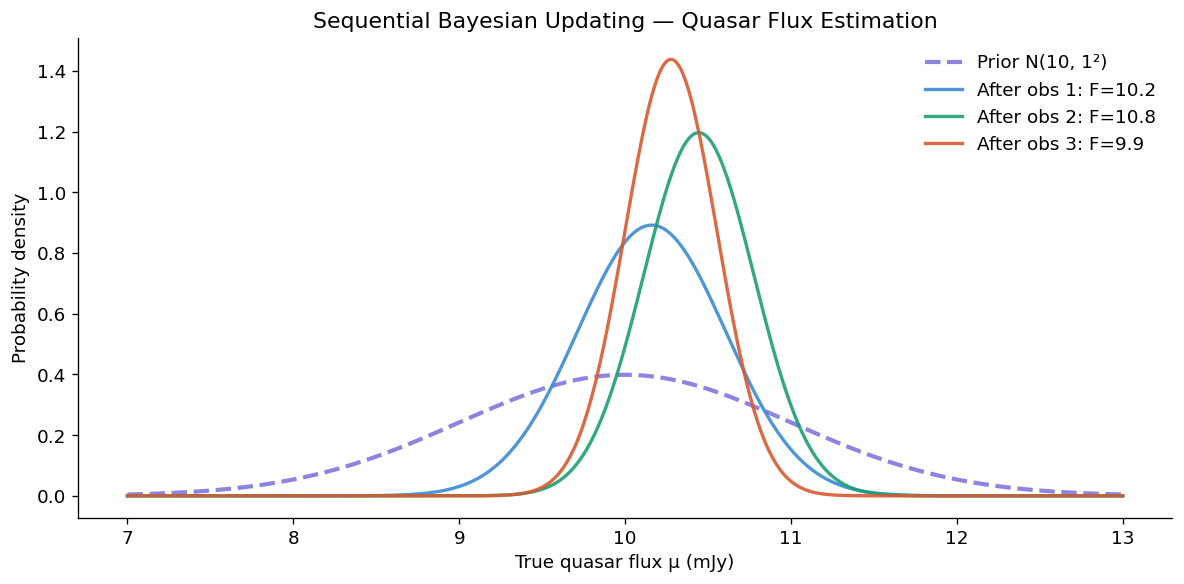

Final posterior: μ = 10.2769 mJy,  σ = 0.2774 mJy
Sample mean:     10.3000 mJy  (for comparison)


In [8]:
# Sequential updating: 3 flux measurements, Gaussian model, Gaussian prior
# Analytic update for Gaussian-Gaussian conjugate model

def gaussian_update(prior_mu, prior_var, likelihood_mu, likelihood_var):
    # Conjugate Gaussian-Gaussian update. Returns posterior (mu, var).
    post_var = 1.0 / (1.0/prior_var + 1.0/likelihood_var)
    post_mu  = post_var * (prior_mu/prior_var + likelihood_mu/likelihood_var)
    return post_mu, post_var

measurements = [10.2, 10.8, 9.9]   # three flux observations (mJy)
sigma_obs    = 0.5                   # known measurement uncertainty

# Start: broad prior
mu0, var0 = 10.0, 1.0**2

mu_grid = np.linspace(7, 13, 500)
fig, ax = plt.subplots(figsize=(10, 5))

current_mu, current_var = mu0, var0
colors = ["#7F77DD", "#3B8BD4", "#1D9E75", "#D85A30"]
labels = ["Prior N(10, 1²)"] + [f"After obs {i+1}: F={m}" for i,m in enumerate(measurements)]

for i, (col, label) in enumerate(zip(colors, labels)):
    pdf = stats.norm.pdf(mu_grid, current_mu, np.sqrt(current_var))
    ax.plot(mu_grid, pdf, color=col, lw=2.5 if i == 0 else 2, label=label,
            ls="--" if i == 0 else "-", alpha=0.9)
    if i < len(measurements):
        current_mu, current_var = gaussian_update(
            current_mu, current_var, measurements[i], sigma_obs**2)

ax.set_xlabel("True quasar flux μ (mJy)")
ax.set_ylabel("Probability density")
ax.set_title("Sequential Bayesian Updating — Quasar Flux Estimation")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Final posterior summary
print(f"Final posterior: μ = {current_mu:.4f} mJy,  σ = {np.sqrt(current_var):.4f} mJy")
print(f"Sample mean:     {np.mean(measurements):.4f} mJy  (for comparison)")


## 2.3 Conjugate Priors — The Beta-Binomial Model

**Problem:** Estimate the detection efficiency ε of a transient-finding pipeline.

We inject known signals and count recoveries. With a Beta prior and Binomial likelihood,
the posterior is analytically a Beta distribution — no numerical integration needed!

$$P(\epsilon \mid k, n) = \text{Beta}(\alpha_0 + k,\; \beta_0 + n - k)$$


Uniform  Beta(1,1): Post mean=0.725,  95% CI=[0.635, 0.807]
Weakly informative  Beta(: Post mean=0.709,  95% CI=[0.621, 0.790]
Informative  Beta(10,2)  : Post mean=0.741,  95% CI=[0.656, 0.818]


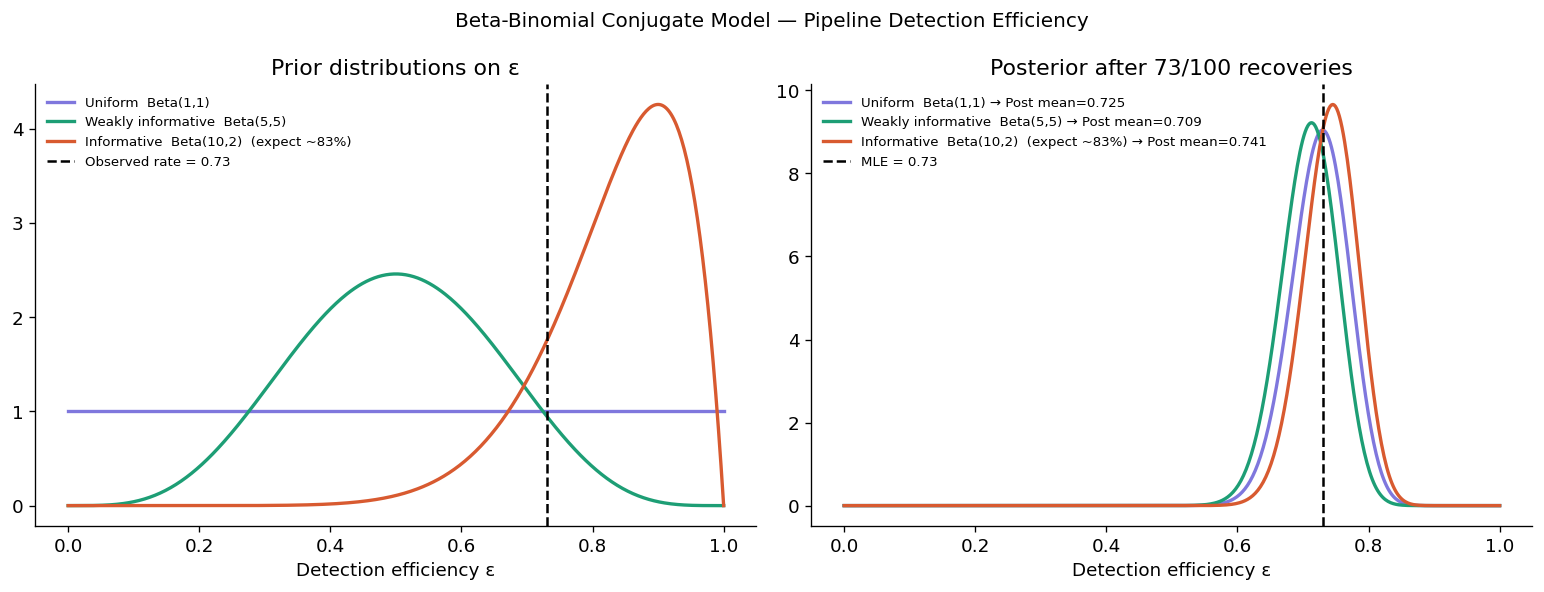

In [10]:
# Beta-Binomial: estimating pipeline detection efficiency
# Scenario: k=73 recovered out of n=100 injected signals

n_injected  = 100
k_recovered = 73

eps_grid = np.linspace(0, 1, 500)

# Three different priors
priors = [
    (1,   1,   "#7F77DD", "Uniform  Beta(1,1)"),
    (5,   5,   "#1D9E75", "Weakly informative  Beta(5,5)"),
    (10,  2,   "#D85A30", "Informative  Beta(10,2)  (expect ~83%)"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for alpha0, beta0, col, label in priors:
    # Prior
    prior_pdf = stats.beta.pdf(eps_grid, alpha0, beta0)
    axes[0].plot(eps_grid, prior_pdf, color=col, lw=2, label=label)

    # Posterior
    alpha_post = alpha0 + k_recovered
    beta_post  = beta0  + (n_injected - k_recovered)
    post_pdf   = stats.beta.pdf(eps_grid, alpha_post, beta_post)
    post_mean  = alpha_post / (alpha_post + beta_post)
    axes[1].plot(eps_grid, post_pdf, color=col, lw=2,
                 label=f"{label} → Post mean={post_mean:.3f}")

    # 95% credible interval
    ci_lo = stats.beta.ppf(0.025, alpha_post, beta_post)
    ci_hi = stats.beta.ppf(0.975, alpha_post, beta_post)
    print(f"{label[:25]}: Post mean={post_mean:.3f},  95% CI=[{ci_lo:.3f}, {ci_hi:.3f}]")

axes[0].axvline(k_recovered/n_injected, ls="--", color="black", lw=1.5,
                label=f"Observed rate = {k_recovered/n_injected:.2f}")
axes[0].set_title("Prior distributions on ε")
axes[0].set_xlabel("Detection efficiency ε")
axes[0].legend(fontsize=8, frameon=False)

axes[1].axvline(k_recovered/n_injected, ls="--", color="black", lw=1.5,
                label=f"MLE = {k_recovered/n_injected:.2f}")
axes[1].set_title(f"Posterior after {k_recovered}/{n_injected} recoveries")
axes[1].set_xlabel("Detection efficiency ε")
axes[1].legend(fontsize=8, frameon=False)

plt.suptitle("Beta-Binomial Conjugate Model — Pipeline Detection Efficiency", fontsize=12)
plt.tight_layout()
plt.show()


## 2.4 Credible Intervals vs. Confidence Intervals

**Bayesian credible interval [a, b] at level 1-α:**  
"There is (1-α) probability that the true θ lies in [a, b], given our model and data."

**Frequentist confidence interval:**  
"If we repeated this experiment many times, (1-α)% of such intervals would contain the true θ."

The credible interval says what scientists **actually want to say**. The confidence interval does not.


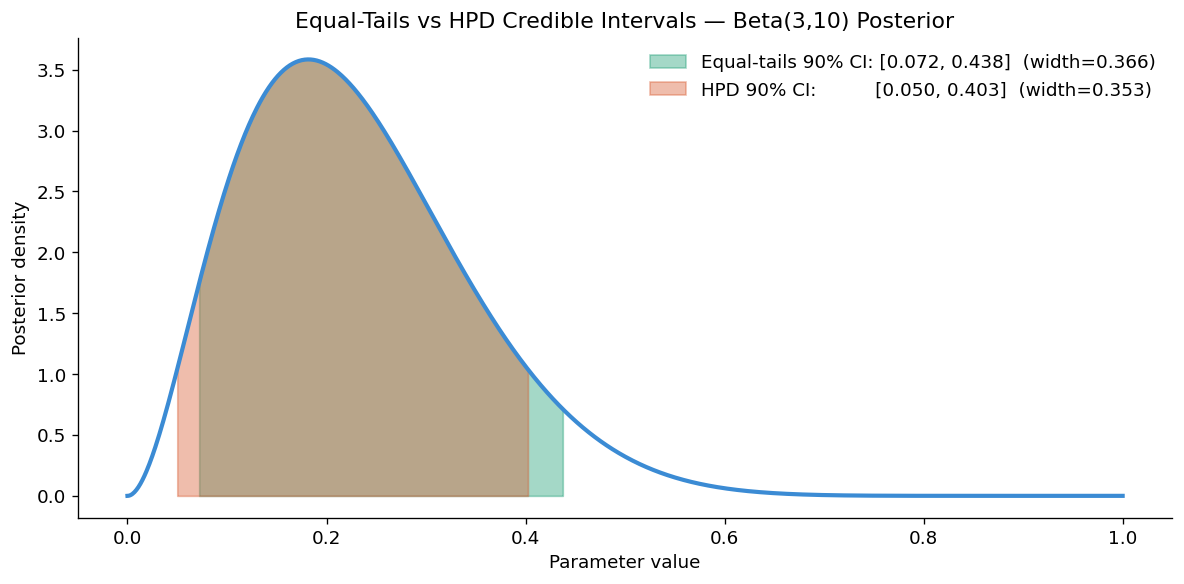

HPD is 0.0134 units narrower — it is the shortest 90% interval.


In [11]:
# Visualise HPD vs equal-tails credible intervals on a skewed posterior
# Posterior: Beta(3, 10) — skewed, like a low-efficiency instrument

alpha_p, beta_p = 3, 10
eps_grid = np.linspace(0, 1, 1000)
pdf = stats.beta.pdf(eps_grid, alpha_p, beta_p)

# Equal-tails 90% CI
lo_et = stats.beta.ppf(0.05, alpha_p, beta_p)
hi_et = stats.beta.ppf(0.95, alpha_p, beta_p)

# HPD interval (shortest interval containing 90%)
from scipy.optimize import minimize_scalar
def interval_width(lo):
    # Width of [lo, hi] where hi is chosen to contain 90% probability.
    hi = stats.beta.ppf(stats.beta.cdf(lo, alpha_p, beta_p) + 0.90, alpha_p, beta_p)
    if np.isnan(hi): return np.inf
    return hi - lo

res = minimize_scalar(interval_width, bounds=(0, 0.1), method="bounded")
lo_hpd = res.x
hi_hpd = stats.beta.ppf(stats.beta.cdf(lo_hpd, alpha_p, beta_p) + 0.90, alpha_p, beta_p)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(eps_grid, pdf, "#3B8BD4", lw=2.5)
ax.fill_between(eps_grid, pdf,
                where=(eps_grid >= lo_et) & (eps_grid <= hi_et),
                color="#1D9E75", alpha=0.4,
                label=f"Equal-tails 90% CI: [{lo_et:.3f}, {hi_et:.3f}]  (width={hi_et-lo_et:.3f})")
ax.fill_between(eps_grid, pdf,
                where=(eps_grid >= lo_hpd) & (eps_grid <= hi_hpd),
                color="#D85A30", alpha=0.4,
                label=f"HPD 90% CI:          [{lo_hpd:.3f}, {hi_hpd:.3f}]  (width={hi_hpd-lo_hpd:.3f})")
ax.set_xlabel("Parameter value")
ax.set_ylabel("Posterior density")
ax.set_title(f"Equal-Tails vs HPD Credible Intervals — Beta({alpha_p},{beta_p}) Posterior")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"HPD is {(hi_et-lo_et)-(hi_hpd-lo_hpd):.4f} units narrower — it is the shortest 90% interval.")


## 2.5 Summary

The Bayesian update rule:

$$\underbrace{P(\theta \mid D)}_{\text{posterior}} \propto \underbrace{P(D \mid \theta)}_{\text{likelihood}} \times \underbrace{P(\theta)}_{\text{prior}}$$

Key takeaways:
- **Sequential updating** is consistent: order of data doesn't matter
- **Conjugate priors** give analytic posteriors (Beta-Binomial, Gaussian-Gaussian, etc.)
- **Credible intervals** say what scientists want: "95% probability the true value is here"
- **MAP** ≈ MLE when priors are uniform; **posterior mean** minimises expected squared error

**Next:** Chapter 3 dives deeper into constructing likelihoods for real astrophysical noise models.


In [12]:
print("Chapter 2 complete!")
print("Key conjugate pairs to remember:")
pairs = [
    ("Poisson likelihood", "Gamma prior", "→ Gamma posterior"),
    ("Binomial likelihood", "Beta prior", "→ Beta posterior"),
    ("Gaussian likelihood (known σ)", "Gaussian prior", "→ Gaussian posterior"),
    ("Multinomial likelihood", "Dirichlet prior", "→ Dirichlet posterior"),
]
for l, p, post in pairs:
    print(f"  {l:40s} + {p:25s} {post}")


Chapter 2 complete!
Key conjugate pairs to remember:
  Poisson likelihood                       + Gamma prior               → Gamma posterior
  Binomial likelihood                      + Beta prior                → Beta posterior
  Gaussian likelihood (known σ)            + Gaussian prior            → Gaussian posterior
  Multinomial likelihood                   + Dirichlet prior           → Dirichlet posterior
